# COM304: Algorithms
##### notebook code (C) 2021-2024 Timothy James Becker
## Chapter 4: Divide and Conquer
## 4.5 <u>Master Method For Recurrence Relations<u>

A faster and easier method for solving specific recurrences that take a certain form and adhere to a set of proximity rules.

#### <u>Theorem 4.1</u>

If the recurrence is of the form:

$T(n) =$<font color="red">$a$</font>$T(n/$<font color="blue">$b$</font>)$ + $<font color="green">$f(n)$</font>$: $<font color="red">$\;\;a$</font>$ \geq 1, $<font color="blue">$b$</font>$ > 1 $ and $ $<font color="green">$f(n)$</font>$ \uparrow$, then:

<b>(1)</b> if $f(n) = O(n^{log_b{a-\epsilon}}): \epsilon>0 \;\implies\; T(n) = \Theta(n^{log_b{a}})$

<b>(2)</b> if $f(n) = \Theta(n^{log_b{a}}): \;\implies\; T(n) = \Theta(n^{log_b{a}}\;lg\;n)$

<b>(3)</b> if $f(n) = \Omega(n^{log_b{a+\epsilon}}): \epsilon>0\;\wedge\; af(n/b) \leq cf(n): c<1 \;\implies\; T(n) = \Theta(f(n))$

we call the $f(n)$ the driving function (you can think of it as the work done to conquer each part of a recursive call in a divid and conquer algorithm.

we call the $aT(n/b)$ the master recurrence (you can think of this as the work being done in the next step and also as the divide in the divide and conquer algorithm)

#### <u>Using the Master Method (correctly)</u>

<b>\[EX 1\]</b>  $T(n) = $<font color="red">$9$</font>$T(n/$<font color="blue">$3$</font>$)+$<font color="green">$n$</font>$: \;\;\;\; $<font color="red">$a$</font>$=? \;\;\;\; $<font color="blue">$b$</font>$=? \;\;\;\; $<font color="green">$f(n)$</font>$=? \;\;\;\; $<font color="brown">$n^{log_b{a}}$</font>$=?$

first examine the form of the recurrence: <font color="red">$a$</font>$=9 \;\;\;\; $<font color="blue">$b$</font>$=3 \;\;\;\; $<font color="green">$f(n)$</font>$=n \;\;\;\; $<font color="brown">$n^{log_b{a}}$</font>$=n^{log_3{9}}=n^2$

next look for one of the three cases to use, lets try <b>(1)</b> if $f(n) = O(n^{log_b{a-\epsilon}}): \epsilon>0$

if we let $\epsilon = 6 \;\implies\;$<font color="green">$f(n)$</font>$ = O(n^{log_3{9-6}}) = O(n^{log_3{3}}) = O(n^1) =O(n)$

and so we now use the result of case <b>(1)</b> $\;\implies\; T(n) = \Theta(n^{log_b{a}}) = \Theta(n^{log_3{9}}) = \Theta(n^2)$



In [1]:
import numpy as np

np.log(14)/np.log(2)

3.8073549220576037

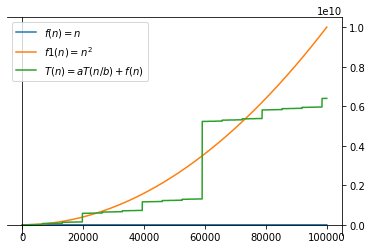

In [4]:
#set up the plotting grid--------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure();ax = fig.add_subplot(1, 1, 1)
ax.spines['bottom'].set_position('zero');ax.spines['left'].set_position('zero')
ax.xaxis.set_ticks_position('bottom');ax.yaxis.set_ticks_position('right')                                           

#master method as a python function----------------------------------------------------
def t_n(n,a,b,f):
    if n<=1: return f(n)
    else:    return a*t_n(n//b,a,b,f) + f(n)
    
#define the f(n) section here----------------------------------------------------------
def f_n(n): return n   #[EX 1]
a,b = 9, 3             #[EX 1]

#plot our results----------------------------------------------------------------------
x = 100000
ns = np.linspace(1,x,x)  
plt.plot(ns,ns,label='$f(n)=n$')
f1 = ns**2                                      
plt.plot(ns,f1,label='$f1(n)=n^2$')
f2 = np.asarray([t_n(i,a,b,f_n) for i in range(x)])
plt.plot(ns,f2,label='$T(n)=aT(n/b)+f(n)$')                                                                                   
plt.legend();plt.show()

<b>\[EX 2\]</b> $T(n) = T(2n/3) + 1$ 

$a=1,\; b = 3/2,\; f(n) = \Theta(1),\; n^{log_b{a}} = n^{log_{3/2}{1}} = n^0 = 1 = \Theta(1)$

lets try case <b>(2)</b> since it seems to match: $f(n) = \Theta(n^{log_b{a}}) \implies T(n) = \Theta(n^{log_b{a}}\;lg\;n) = \Theta(n^{log_{3/2}{1}}\;lg\;n) = \Theta(1\;lg\;n) = \Theta(lg\;n)$


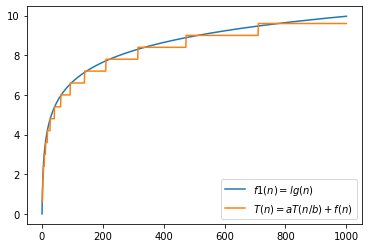

In [92]:
#define the f(n) section here----------------------------------------------------------
def f_n(n): return 0.6 #[EX 2]
a,b = 1, 3/2           #[EX 2]

#plot our results----------------------------------------------------------------------
x = 1000
ns = np.linspace(1,x,x)  
f1 = np.log(ns)/np.log(2)                                     
plt.plot(ns,f1,label='$f1(n)=lg(n)$')
f2 = np.asarray([t_n(i,a,b,f_n) for i in range(x)])
plt.plot(ns,f2,label='$T(n)=aT(n/b)+f(n)$')                                                                                   
plt.legend();plt.show()

<b>\[EX 3\]</b> $T(n) = 3T(n/4) + n\;lg\;n$

$a=3,\; b=4,\; f(n) = n\;lg\;n,\; n^{log_b{a}}= n^{log_4{3}} < n^1 = n$

lets try case <b>(1)</b>: $f(n) = O(n^{log_b{a-\epsilon}}): \epsilon>0 \;$ but even as $\;\lim\limits_{\epsilon \to 0} n^{log_b{a}} = n^{log_4{3}}<n^1$ so this doesn't hold...

lets look at case <b>(2)</b> $f(n) = \Theta(n^{log_b{a}})\;$ but since $\;f(n) = n\;lg\;n\;$ here it is off by $lg\;n$ so this doesn't hold

lets try case <b>(3)</b> $f(n) = \Omega(n^{log_b{a+\epsilon}}): \epsilon>0\;\wedge\; af(n/b) \leq cf(n): c<1$

$n\;lg\;n = f(n) = \Omega(n^1)\;$ so the first part holds, now we need to check the regularity condition:

$af(n/b) \leq cf(n): c < 1$

$3[(n/4)lg(n/4)] \leq c\;n\;lg\;n$

$\frac{3}{4}n\;lg(n/4) \leq c\;n\;lg\;n\;$ let $c=\frac{3}{4}\;$ then:


$n\;lg(n/4) \leq \;n\;lg\;n\;$ holds so we can use the result: $\implies T(n) = \Theta(f(n)) = \Theta()$

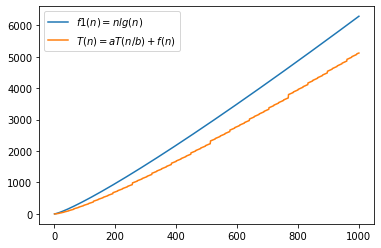

In [91]:
#define the f(n) section here----------------------------------------------------------
def f_n(n): return 0.38*n*np.log1p(n)/np.log1p(2)   #[EX 3]
a,b = 3, 4                                          #[EX 3]

#plot our results----------------------------------------------------------------------
x = 1000
ns = np.linspace(1,x,x)  
f1 = ns*np.log1p(ns)/np.log1p(2)                                     
plt.plot(ns,f1,label='$f1(n)=nlg(n)$')
f2 = np.asarray([t_n(i,a,b,f_n) for i in range(x)])
plt.plot(ns,f2,label='$T(n)=aT(n/b)+f(n)$')                                                                                   
plt.legend();plt.show()

#### <u>Practice</u> 
(3e) 4.5-1 a, 4.5-4 <br>
(4e) 4.5-1 a, 4.5-4 omitted...